In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [3]:
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop", "gdppc", "iso3"]
]

In [22]:
POREALLAS_PARSED_ERA5_URI = "gs://poreallas-public-20260605/v20260731/parsed/era5.zarr"
ERA5_RECENT = "/home/emily_zuetell/projects/poreallas/data/parsed/26_era5_daily_running.zarr"
POREALLAS_PARSED_FORECAST_URI = "/home/emily_zuetell/projects/poreallas/data/parsed/08_ecmwf_parsed.zarr"

In [ ]:
era5 = xr.load_dataset(
        POREALLAS_PARSED_ERA5_URI,
        engine="zarr",
        backend_kwargs={"storage_options": {"token": "anon"}},
    ).resample(time='MS').mean()
era5_recent = xr.open_zarr(ERA5_RECENT).resample(time='MS').mean().rename({'t2m': 'tas'})
era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 2026 ERA5 data

/tmp/ipykernel_1080/3536011566.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  era5_full = xr.merge([era5, era5_recent])
/tmp/ipykernel_1080/3536011566.py:7: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  era5_full = xr.merge([era5, era5_recent])


In [41]:
forecast = xr.open_zarr(
        POREALLAS_PARSED_FORECAST_URI)

In [42]:
# Baseline period (1995-2014)
era5_base = era5.sel(time=slice("1995-01-01", "2014-12-31")).groupby('time.month').mean()
forecast_base = forecast.sel(time=slice("1995-01-01", "2014-12-31")).groupby('time.month').mean()

In [ ]:
# Analysis Period (1995-2027)
era5_analysis = era5_full.sel(time=slice("1995-01-01", "2026-07-31")).resample(time='MS').mean()
forecast_analysis = forecast.sel(time=slice("2026-08-01", "2027-02-28")).resample(time='MS').mean().mean(dim=['number'])    

In [ ]:
# Subtract Monthly Climatology
era5_anomaly = era5_analysis.groupby('time.month') - era5_base
forecast_anomaly = forecast_analysis.groupby('time.month') - forecast_base

In [56]:
# Convert Ensemble Average to Impact Regions
anomaly_era5_ir = isku_utils.grid_to_ir(era5_anomaly['tas'], savefile="anomaly_era5_ir")
anomaly_forecast_ir = isku_utils.grid_to_ir(forecast_anomaly['tas'], savefile="anomaly_forecast_ir")


/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is

In [66]:
merged_era5 = xr.merge([anomaly_era5_ir.rename('anomaly'), socioeconomics])
merged_forecast = xr.merge([anomaly_forecast_ir.rename('anomaly'), socioeconomics])

In [68]:
pop_weighted_anomaly_era5 = (merged_era5['anomaly'] * merged_era5['pop']).sum(dim='region') / merged_era5['pop'].sum(dim='region')
pop_weighted_anomaly_forecast = (merged_forecast['anomaly'] * merged_forecast['pop']).sum(dim='region') / merged_forecast['pop'].sum(dim='region')

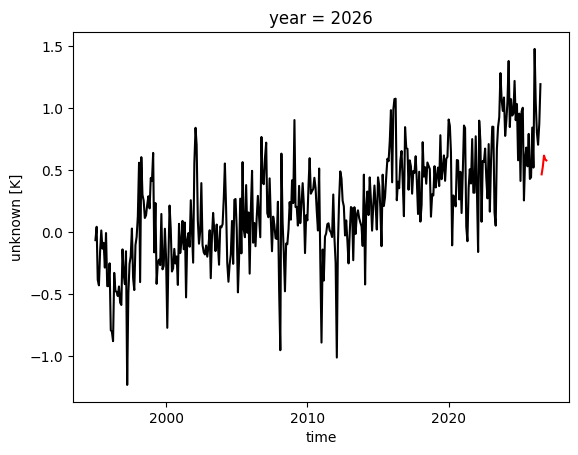

In [ ]:
pop_weighted_anomaly_era5.plot(color = 'k')
pop_weighted_anomaly_forecast.mean(dim='number').plot(color = 'r')